# Espectro Sísmico de Diseño — NCh2369:2025

Genera y visualiza el espectro de respuesta de diseño según la norma chilena **NCh2369:2025** para estructuras industriales.

**Uso:** edita la celda de parámetros (Sección 1), luego ejecuta todo el notebook (`Run All`).

| Entrada | Descripción |
|---------|-------------|
| `zona` | Zona sísmica (1, 2 ó 3) |
| `suelo` | Tipo de suelo (A, B, C, D ó E) |
| `I` | Factor de importancia |
| `R_x`, `xi_x` | Factor de reducción y amortiguamiento — dirección X |
| `R_y`, `xi_y` | Factor de reducción y amortiguamiento — dirección Y |
| `R_v`, `xi_v` | Factor de reducción y amortiguamiento — dirección vertical |

In [1]:
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import handcalcs.render  # registra las magias %%render y %%tex
from IPython.display import display

---
## 1. Parámetros de Entrada

Edita los valores a continuación y ejecuta el notebook completo.

In [2]:
# ╔══════════════════════════════════════════════════════╗
# ║           EDITAR ESTA CELDA CON TUS VALORES          ║
# ╚══════════════════════════════════════════════════════╝

# ── Parámetros del sitio ─────────────────────────────────
zona  = 2        # Zona sísmica: 1, 2 ó 3
suelo = "C"      # Tipo de suelo: "A", "B", "C", "D" ó "E"
I     = 1.0      # Factor de importancia I  (≥ 1.0)

# ── Dirección Horizontal X ───────────────────────────────
R_x  = 3.0       # Factor de reducción R — eje X
xi_x = 0.03      # Amortiguamiento ξ — eje X  (0.03 = 3 %)

# ── Dirección Horizontal Y ───────────────────────────────
R_y  = 3.0       # Factor de reducción R — eje Y
xi_y = 0.03      # Amortiguamiento ξ — eje Y  (0.03 = 3 %)

# ── Dirección Vertical ───────────────────────────────────
R_v  = 2.0       # Factor de reducción R — vertical
xi_v = 0.03      # Amortiguamiento ξ — vertical  (0.03 = 3 %)

In [3]:
from dataclasses import dataclass

# ── Aceleración efectiva por zona (fracción de g) ────────
AR_BY_ZONE = {1: 0.28, 2: 0.42, 3: 0.56}

# ── Parámetros de suelo NCh2369:2025 ────────────────────
@dataclass(frozen=True)
class SoilParameters:
    S: float   # Amplificador de sitio
    r: float   # Razón espectral
    T0: float  # Período de control [s]
    p: float   # Exponente ascendente
    q: float   # Exponente descendente
    T1: float  # Período de esquina T1 [s]

SOIL_PARAMS = {
    "A": SoilParameters(S=0.90, r=4.50, T0=0.15, p=1.85, q=3.00, T1=0.15),
    "B": SoilParameters(S=1.00, r=4.50, T0=0.30, p=1.60, q=3.00, T1=0.27),
    "C": SoilParameters(S=1.05, r=4.50, T0=0.40, p=1.50, q=3.00, T1=0.35),
    "D": SoilParameters(S=1.00, r=3.50, T0=0.60, p=1.00, q=2.50, T1=0.41),
    "E": SoilParameters(S=1.00, r=3.00, T0=1.20, p=1.00, q=2.70, T1=0.79),
}

# ── Extraer parámetros según la selección del usuario ───
assert zona  in AR_BY_ZONE,  f"zona debe ser 1, 2 ó 3 — se recibió: {zona}"
assert suelo in SOIL_PARAMS, f"suelo debe ser A, B, C, D ó E — se recibió: {suelo!r}"
assert I >= 1.0, "El factor de importancia I debe ser ≥ 1.0"

Ar = AR_BY_ZONE[zona]
sp = SOIL_PARAMS[suelo]

print(f"Zona {zona}  |  Suelo {suelo}  |  Ar = {Ar:.2f} g")

Zona 2  |  Suelo C  |  Ar = 0.42 g


In [4]:
%%render params
Ar = Ar         # Aceleración efectiva de zona [g]
S  = sp.S       # Amplificador de sitio
r  = sp.r       # Razón espectral
T0 = sp.T0      # Período de control T₀ [s]
p  = sp.p       # Exponente ascendente
q  = sp.q       # Exponente descendente
T1 = sp.T1      # Período de esquina T₁ [s]

<IPython.core.display.Latex object>

---
## 2. Formulación

La aceleración espectral de diseño $S_a(T)$ se calcula en tres pasos:

**1. Forma espectral bruta** (antes de reducción):

$$S_a^{\text{bruta}}(T) = A_r \cdot S \cdot \dfrac{1 + r \cdot \left(\dfrac{T'}{T_0}\right)^p}{1 + \left(\dfrac{T'}{T_0}\right)^q}$$

donde $T' = \alpha_T \cdot T$ ($\alpha_T = 1{,}0$ horizontal, $1{,}7$ vertical).

**2. Factor de amortiguamiento:**

$$\eta = \left(\dfrac{0{,}05}{\xi}\right)^{0{,}4}$$

**3. Espectro de diseño reducido:**

$$S_a(T) = I \cdot \eta \cdot \dfrac{S_a^{\text{bruta}}(T)}{R^*(T)}$$

$R^*$ interpola linealmente desde $1{,}5$ hasta $R$ en el rango $T \in [0,\; 0{,}16 \cdot R \cdot T_1]$ (solo horizontal).

### Verificación numérica en $T = T_0$ (período de control del suelo)

Se evalúa el espectro horizontal X en el período $T = T_0$, donde la forma espectral alcanza su máximo.

In [5]:
%%render
# Evaluación del espectro horizontal X en T = T0 (sin R*, asumiendo T0 >> límite corto)
T_v = sp.T0       # Período de evaluación = T0  [s]
ratio_v = T_v / sp.T0
Sa_bruta = Ar * sp.S * (1 + sp.r * ratio_v**sp.p) / (1 + ratio_v**sp.q)
eta_x = (0.05 / xi_x)**0.4     # Factor de amortiguamiento eje X
Sa_X_T0 = I * eta_x * Sa_bruta / R_x    # Aceleración de diseño [g]

<IPython.core.display.Latex object>

---
## 3. Funciones de Cálculo

In [6]:
def _spectrum_shape(ar, sp, T, scale_factor=1.0, period_shift=1.0):
    """Forma espectral Sa(T) — sin reducción R ni corrección de amortiguamiento."""
    if T == 0:
        return scale_factor * ar * sp.S
    T_shifted = period_shift * T
    ratio = T_shifted / sp.T0
    num = 1.0 + sp.r * (ratio ** sp.p)
    den = 1.0 + (ratio ** sp.q)
    return scale_factor * ar * sp.S * num / den


def _r_star(T, R, t1):
    """R* — reducción lineal para períodos cortos (NCh2369 §6.3.3)."""
    limit = 0.16 * R * t1
    if limit <= 0 or T >= limit:
        return R
    return 1.5 + (R - 1.5) * (T / limit)


def compute_spectrum(zone, soil, I, R, damp,
                     scale_factor=1.0, period_shift=1.0, apply_r_star=True):
    """Genera el espectro de diseño NCh2369 completo (0 a 5 s).

    Retorna dos listas: (períodos [s], aceleraciones [g]).
    """
    ar = AR_BY_ZONE[zone]
    sp = SOIL_PARAMS[soil]
    damping_scale = (0.05 / damp) ** 0.4

    periods, accels = [], []
    for i in range(501):
        T = round(i * 0.01, 4)
        sa = _spectrum_shape(ar, sp, T, scale_factor, period_shift)
        r_eff = _r_star(T, R, sp.T1) if apply_r_star else R
        periods.append(T)
        accels.append(I * sa * damping_scale / r_eff)

    return periods, accels

In [7]:
# ── Espectro Horizontal X ────────────────────────────────
T_x, Sa_x = compute_spectrum(zona, suelo, I, R_x, xi_x,
                              scale_factor=1.0, period_shift=1.0, apply_r_star=True)

# ── Espectro Horizontal Y ────────────────────────────────
if R_y == R_x and xi_y == xi_x:
    T_y, Sa_y = T_x, Sa_x   # idéntico a X — no se grafica por separado
    same_xy = True
else:
    T_y, Sa_y = compute_spectrum(zona, suelo, I, R_y, xi_y,
                                  scale_factor=1.0, period_shift=1.0, apply_r_star=True)
    same_xy = False

# ── Espectro Vertical (escala 0.7, período 1.7T, sin R*) ─
T_v_full, Sa_v = compute_spectrum(zona, suelo, I, R_v, xi_v,
                                   scale_factor=0.7, period_shift=1.7, apply_r_star=False)

print("Espectros calculados correctamente.")

Espectros calculados correctamente.


---
## 4. Espectro de Diseño

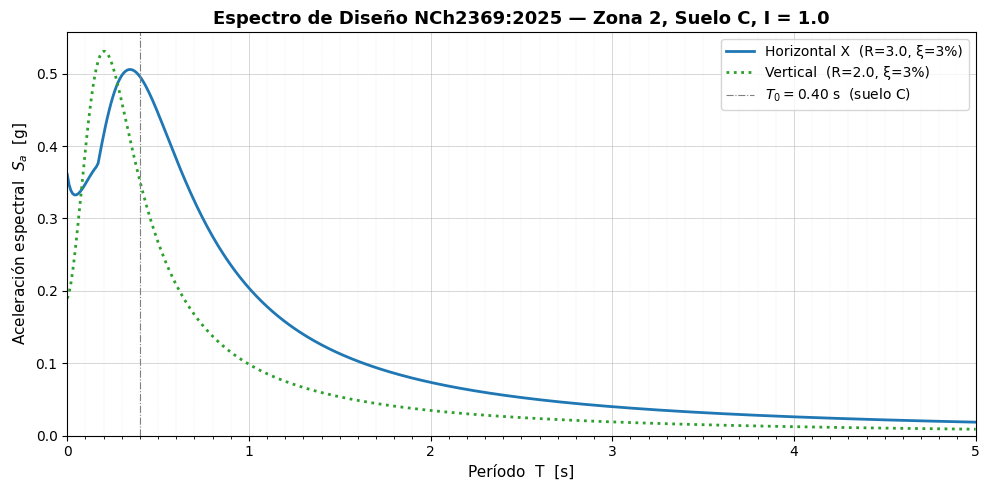

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

# Curva Horizontal X
ax.plot(T_x, Sa_x, color="#1f77b4", linewidth=2,
        label=f"Horizontal X  (R={R_x}, ξ={xi_x:.0%})")

# Curva Horizontal Y — solo si difiere de X
if not same_xy:
    ax.plot(T_y, Sa_y, color="#ff7f0e", linewidth=2, linestyle="--",
            label=f"Horizontal Y  (R={R_y}, ξ={xi_y:.0%})")

# Curva Vertical
ax.plot(T_v_full, Sa_v, color="#2ca02c", linewidth=2, linestyle=":",
        label=f"Vertical  (R={R_v}, ξ={xi_v:.0%})")

# Línea vertical en T0 del suelo
ax.axvline(sp.T0, color="grey", linewidth=0.8, linestyle="-.",
           label=f"$T_0 = {sp.T0:.2f}$ s  (suelo {suelo})")

ax.set_title(
    f"Espectro de Diseño NCh2369:2025 — Zona {zona}, Suelo {suelo}, I = {I:.1f}",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Período  T  [s]", fontsize=11)
ax.set_ylabel("Aceleración espectral  $S_a$  [g]", fontsize=11)
ax.set_xlim(0, 5.0)
ax.set_ylim(bottom=0)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax.grid(which="major", linestyle="-", linewidth=0.5, alpha=0.7)
ax.grid(which="minor", linestyle=":", linewidth=0.3, alpha=0.5)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 5. Tabla de Valores

In [9]:
T_TABLA = [0.00, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50,
           0.75, 1.00, 1.25, 1.50, 2.00, 2.50, 3.00, 4.00, 5.00]

def _interp(T_list, Sa_list, T_query):
    """Interpola Sa en T_query desde las listas del espectro."""
    idx = round(T_query / 0.01)
    idx = max(0, min(idx, len(Sa_list) - 1))
    return Sa_list[idx]

rows = []
for T_q in T_TABLA:
    rows.append({
        "T [s]":    T_q,
        "Sa X [g]": _interp(T_x, Sa_x, T_q),
        "Sa Y [g]": _interp(T_y, Sa_y, T_q),
        "Sa V [g]": _interp(T_v_full, Sa_v, T_q),
    })

df = pd.DataFrame(rows)
display(df.style
          .format({"T [s]": "{:.2f}", "Sa X [g]": "{:.4f}",
                   "Sa Y [g]": "{:.4f}", "Sa V [g]": "{:.4f}"})
          .set_caption(
              f"Espectro NCh2369:2025 — Zona {zona}, Suelo {suelo}, I = {I:.1f}"
          )
          .hide(axis="index")
)

T [s],Sa X [g],Sa Y [g],Sa V [g]
0.00,0.3607,0.3607,0.1893
0.05,0.3326,0.3326,0.2702
0.10,0.3478,0.3478,0.3951
0.15,0.3680,0.3680,0.4948
0.20,0.4153,0.4153,0.5310
0.30,0.4975,0.4975,0.4608
0.40,0.4959,0.4959,0.3514
0.50,0.4451,0.4451,0.2670
0.75,0.2982,0.2982,0.1509
1.00,0.2038,0.2038,0.0984
